# Geodesics in the Schwarzschild Metric

### Load libraries and constants
We will be using dimensionless constants for ease of use.

In [24]:
# Numerical Integration
from scipy.integrate import solve_ivp

# Mathematics
import numpy as np

# Plotting and Animation
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# Constants
c = 1
G = 1
M = 1
pi = np.pi

### Co-ordinates
We use the state $(t, r, \theta, \phi)$. We keep this in a state `s`. However, we must also encode the velocity in `u`.

In [158]:
#s0 = [0, 6, pi/2, 0]
#u0 = [np.sqrt(111/2), 0, 0, 1] # need to implement a function to generate random states with proper normalisation

def generate_random_state():

    done = False

    position = [0, np.random.uniform(3.5, 10), np.random.uniform(-pi, pi), 0]
    gamma = np.random.uniform(1.5, 10)
    v = [np.random.uniform(-1, 1), np.random.uniform(0.2, 0.2), np.random.uniform(0.1, 0.1)]

    num = (gamma**2 * (1 - 2*M/position[1]) - 1)
    denum = v[0]**2 / (1 - 2*M/position[1]) + position[1]**2 * v[1]**2 + position[1]**2 * np.sin(position[2])**2 * v[2]**2
    factor = np.sqrt(num / denum)
    
    x = np.concatenate([position, [gamma], np.array(v)/factor])

    return x
    

#state0 = s0 + u0
state0 = generate_random_state()

### Geodesic Equations in the Schwarzschild Metric

The four geodesic equations for massive test particles in the Schwarzschild metric are
$$
\begin{align*}
\frac{\textrm{d}^2 t}{\textrm{d} \tau^2} &= - 2\frac{M}{r^2} \left( 1 - \frac{2M}{r}\right)^{-1} \frac{\textrm{d}t}{\textrm{d}\tau} \frac{\textrm{d} r}{\textrm{d} \tau}\\
\frac{\textrm{d}^2 r}{\textrm{d} \tau^2} &= - \frac{M}{r^2} \left(1 - \frac{2M}{r} \right) \frac{\textrm{d} t }{\textrm{d}\tau}\frac{\textrm{d} t}{\textrm{d} \tau} + \frac{M}{r^2} \left(1 - \frac{2M}{r}\right)^{-1} \frac{\textrm{d} r}{\textrm{d} \tau} \frac{\textrm{d}r}{\textrm{d}\tau} + (r-2M) \frac{\textrm{d} \theta}{\textrm{d} \tau} \frac{\textrm{d} \theta}{\textrm{d}\tau} + (r-2M) \sin^2 \theta \frac{\textrm{d}\phi}{\textrm{d}\tau} \frac{\textrm{d} \phi}{\textrm{d}\tau}\\
\frac{\textrm{d}^2 \theta}{\textrm{d} \tau^2} &= - \frac{2}{r} \frac{\textrm{d} r}{\textrm{d} \tau} \frac{\textrm{d} \theta}{\textrm{d} \tau} + \cos \theta \sin \theta \frac{\textrm{d}\phi}{\textrm{d}\tau}\frac{\textrm{d}\phi}{\textrm{d}\tau}\\
\frac{\textrm{d}^2 \phi}{\textrm{d}\tau^2} &= - \frac{2}{r} \frac{\textrm{d} r}{\textrm{d}\tau} \frac{\textrm{d} \phi}{\textrm{d} \tau} - 2 \cot \theta \frac{\textrm{d} \theta}{\textrm{d}\tau} \frac{\textrm{d} \phi}{\textrm{d} \tau}
\end{align*}
$$

For a massless particle (ie. photons), we will use $\lambda$ instead of $\tau$ which stands in for a parameter that is varied between $0$ and $1$ (or whatever your heart desires) between some two points that are on the trajectory.

In [159]:
def deriv_mass(tau, state):

    s = state[0:4]
    u = state[4:]
    
    t, r, theta, phi = s
    dt_dtau, dr_dtau, dtheta_dtau, dphi_dtau = u
    
    ds_dtau = u


    d2t_dtau2 = -2*M * dt_dtau * dr_dtau / (r**2 * (1 - 2*M/r))
    d2r_dtau2 = - M * (1 - 2*M/r) * dt_dtau**2 / r**2 \
                + M * dr_dtau**2 / (r**2 * (1 - 2*M/r)) \
                + (r - 2*M) * dtheta_dtau**2 \
                + (r - 2*M) * np.sin(theta)**2 * dphi_dtau**2
    d2theta_dtau2 = -2 * dr_dtau * dtheta_dtau / r \
                    + np.sin(theta) * np.cos(theta) * dphi_dtau**2
    d2phi_dtau2 = - 2 * dr_dtau * dphi_dtau / r \
                - 2 * dtheta_dtau * dphi_dtau / np.tan(theta)

    du_dtau = [d2t_dtau2, d2r_dtau2, d2theta_dtau2, d2phi_dtau2]
    return np.concatenate([u, du_dtau])

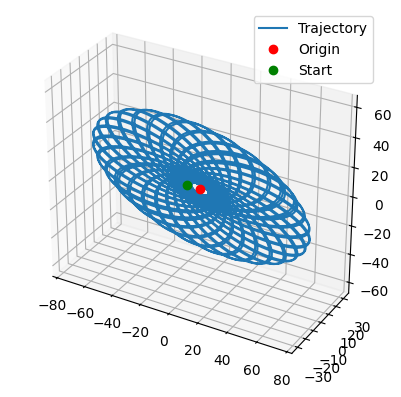

In [166]:
#state0 = generate_random_state()
solution = solve_ivp(deriv_mass, [0, 30000], state0, max_step = 0.01)

tvals = solution.t
state_vals = solution.y

x = state_vals[1] * np.cos(state_vals[3]) * np.sin(state_vals[2])
y = state_vals[1] * np.sin(state_vals[3]) * np.sin(state_vals[2])
z = state_vals[1] * np.cos(state_vals[2])
ax = plt.figure().add_subplot(projection="3d")
plt.plot(x, y, z, label="Trajectory")
plt.plot(0, 0, "ro", label="Origin")
plt.plot(x[0], y[0], z[0], "go", label="Start")
ax.set_aspect("equal")
plt.legend()
plt.show()

## Generalised Solver
Now, we write a solver for when we don't have such nice forms for the Christoffel symbols.

Specifically, the geodesic equations is
$$
\frac{\textrm{d}^2 x^{\alpha}}{\textrm{d}\tau^2} = - \Gamma^{\alpha}_{\beta \gamma} \frac{\textrm{d}x^\beta}{\textrm{d}\tau} \frac{\textrm{d} x^\gamma}{\textrm{d} \tau}
$$
We can solve this with matrix methods.
In particular, we denote $\Gamma$ to be a 3-D matrix, containing all the Christoffel Symbols. Then, by multiplying along certain dimensions we will end up with a vector in return. Specifically, we will need to multiply by $u$ twice in order to get the multiplication desired.

In [172]:
def generate_christoffel_symbols(state):
    t, r, theta, phi = state[0:4]
    gamma_t = [[0,0,0,0], [0,0,0,0], [0,0,0,0], [0,0,0,0]]
    gamma_r = [[0,0,0,0], [0,0,0,0], [0,0,0,0], [0,0,0,0]]
    gamma_theta = [[0,0,0,0], [0,0,0,0], [0,0,0,0], [0,0,0,0]]
    gamma_phi = [[0,0,0,0], [0,0,0,0], [0,0,0,0], [0,0,0,0]]

    return [gamma_t, gamma_r, gamma_theta, gamma_phi]

### Geodesic Equations
So, we have the Christoffel symbols now. We need to formulate the geodesic equations in terms of this matrix. We see that for each element we pick the relevant 2D matrix. Then, we multiply on the left and right by $u$, which yields the $\dot{u}$.

In [177]:
def mass_deriv(tau, state):

    u = state[4:]
    christoffel = generate_christoffel_symbols(state)

    du_dtau = np.dot(u, np.dot(christoffel, u))

    print(du_dtau)

    return np.concatenate(u, du_dtau)

### Special Settings
Below are some settings that illustrate interesting phenomena!

In [167]:
# Precession of the perhilion - Run for 3000
state0 = np.array([ 0, 9.1995625, -1.54928506, 0, 3.99018725, 0.62698797, 0.13619518, 0.06809759])